**1. Data Loading and preprocessing**

In [2]:
import pandas as pd
import numpy as np
import re
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import datetime
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

In [3]:
# Load the TSV file without setting custom column names to retain the original header
behaviors_df = pd.read_csv("./MINDsmall_train/behaviors.tsv", sep="\t", header=None)

# 1️⃣ Handle Missing Values
# Option 1: Drop rows with missing 'history'
behaviors_df.dropna(subset=[3], inplace=True)  # Adjust index based on the original structure

# 2️⃣ Convert 'time' to datetime
behaviors_df[2] = pd.to_datetime(behaviors_df[2])  # Convert time column (index 2)

# 3️⃣ Convert 'history' to a list of news IDs
behaviors_df[3] = behaviors_df[3].apply(
    lambda x: x.split() if isinstance(x, str) and x.strip() else []
)

# 4️⃣ Convert 'impressions' to a list of tuples
behaviors_df[4] = behaviors_df[4].apply(
    lambda x: [(item.split('-')[0], int(item.split('-')[1])) for item in x.split()] if pd.notna(x) else []
)

# 5️⃣ Expand 'impressions' into separate rows
expanded_rows = []
for _, row in behaviors_df.iterrows():
    impression_id = int(row[0])  # Convert Impression ID to integer
    user_id = str(row[1])        # Convert User ID to string
    timestamp = row[2]           # Already a datetime object
    history = row[3]             # List of news IDs
    # Extract impressions
    impressions = row[4]         # List of (news_id, label) tuples
    for news_id, label in impressions:
        expanded_rows.append([impression_id, user_id, timestamp, history, news_id, label])

# Create a new DataFrame with expanded impressions
expanded_behaviors_df = pd.DataFrame(expanded_rows, columns=['impression_id', 'user_id', 'time', 'history', 'news_id', 'label'])

# Ensure correct data types
expanded_behaviors_df['impression_id'] = expanded_behaviors_df['impression_id'].astype(int)
expanded_behaviors_df['user_id'] = expanded_behaviors_df['user_id'].astype(str)
expanded_behaviors_df['time'] = pd.to_datetime(expanded_behaviors_df['time'])
# Convert 'history' to a list of strings
expanded_behaviors_df['history'] = expanded_behaviors_df['history'].apply(
    lambda x: list(x) if isinstance(x, list) else []
)
expanded_behaviors_df['news_id'] = expanded_behaviors_df['news_id'].astype(str)
expanded_behaviors_df['label'] = expanded_behaviors_df['label'].astype(int)

# Display the DataFrame to verify the changes
print(expanded_behaviors_df.head())
print(expanded_behaviors_df.info())

   impression_id user_id                time  \
0              1  U13740 2019-11-11 09:05:58   
1              1  U13740 2019-11-11 09:05:58   
2              2  U91836 2019-11-12 18:11:30   
3              2  U91836 2019-11-12 18:11:30   
4              2  U91836 2019-11-12 18:11:30   

                                             history news_id  label  
0  [N55189, N42782, N34694, N45794, N18445, N6330...  N55689      1  
1  [N55189, N42782, N34694, N45794, N18445, N6330...  N35729      0  
2  [N31739, N6072, N63045, N23979, N35656, N43353...  N20678      0  
3  [N31739, N6072, N63045, N23979, N35656, N43353...  N39317      0  
4  [N31739, N6072, N63045, N23979, N35656, N43353...  N58114      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3  

In [4]:
# Renaming the DataFrame from expanded_behaviors_df to behaviors_df
behaviors_df = expanded_behaviors_df.copy()

# Displaying the renamed DataFrame and its info to verify the changes
behaviors_df.head(), behaviors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3   history        object        
 4   news_id        object        
 5   label          int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 262.0+ MB


(   impression_id user_id                time  \
 0              1  U13740 2019-11-11 09:05:58   
 1              1  U13740 2019-11-11 09:05:58   
 2              2  U91836 2019-11-12 18:11:30   
 3              2  U91836 2019-11-12 18:11:30   
 4              2  U91836 2019-11-12 18:11:30   
 
                                              history news_id  label  
 0  [N55189, N42782, N34694, N45794, N18445, N6330...  N55689      1  
 1  [N55189, N42782, N34694, N45794, N18445, N6330...  N35729      0  
 2  [N31739, N6072, N63045, N23979, N35656, N43353...  N20678      0  
 3  [N31739, N6072, N63045, N23979, N35656, N43353...  N39317      0  
 4  [N31739, N6072, N63045, N23979, N35656, N43353...  N58114      0  ,
 None)

In [5]:
behaviors_df

,impression_id,user_id,time,history,news_id,label
0,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...",N55689,1
1,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...",N35729,0
2,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N20678,0
3,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N39317,0
4,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N58114,0
...,...,...,...,...,...,...
5722997,156964,U44625,2019-11-13 14:57:02,"[N4118, N47297, N3164, N43295, N6056, N38747, ...",N39317,0
5722998,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N61233,0
5722999,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N33828,1
5723000,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N19661,0


In [6]:
behaviors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3   history        object        
 4   news_id        object        
 5   label          int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 262.0+ MB


In [7]:
# Load the dataset
news_df = pd.read_csv("./MINDsmall_train/news.tsv", sep="\t", header=None)

# Define column names based on your description
news_df.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 
                   'url', 'title_entities', 'abstract_entities']

# 1️⃣ Handle Missing Values
# Fill missing title and abstract with placeholders or drop them
news_df['title'].fillna("No Title Available", inplace=True)
news_df['abstract'].fillna("No Abstract Available", inplace=True)

# 2️⃣ Convert JSON-like entity columns to actual lists
def parse_entities(x):
    try:
        return json.loads(x) if pd.notna(x) and x.strip() else []
    except json.JSONDecodeError:
        return []

news_df['title_entities'] = news_df['title_entities'].apply(parse_entities)
news_df['abstract_entities'] = news_df['abstract_entities'].apply(parse_entities)

# 3️⃣ Text Preprocessing
def clean_text(text):
    """Clean the text by removing unwanted characters and converting to lowercase."""
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text.lower().strip()  # Convert to lowercase and remove extra spaces

news_df['title'] = news_df['title'].apply(clean_text)
news_df['abstract'] = news_df['abstract'].apply(clean_text)

# 4️⃣ Normalize Data
# Convert news_id to string (if necessary) to maintain consistent data types
news_df['news_id'] = news_df['news_id'].astype(str)

/var/folders/xm/dm9zr34x47149ff4w18th5x40000gp/T/ipykernel_65424/2207453352.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  news_df['title'].fillna("No Title Available", inplace=True)
/var/folders/xm/dm9zr34x47149ff4w18th5x40000gp/T/ipykernel_65424/2207453352.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

In [8]:
# news_df['text_content'] = (
#     news_df['category'] + ' ' + 
#     news_df['subcategory'] + ' ' + 
#     news_df['title'] + ' ' + 
#     news_df['abstract']
# )
# news_df.head()

In [9]:
# news_df['entity_labels'] = news_df['title_entities'].apply(
#     lambda x: ' '.join([entity['Label'].lower() for entity in x]) if isinstance(x, list) else ''
# ) + ' ' + news_df['abstract_entities'].apply(
#     lambda x: ' '.join([entity['Label'].lower() for entity in x]) if isinstance(x, list) else ''
# )

# # Append extracted entities to text content
# news_df['text_content'] = news_df['text_content'] + ' ' + news_df['entity_labels']
# news_df.head()

In [10]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD
# from sklearn.metrics.pairwise import cosine_similarity

In [11]:
# tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
# tfidf_matrix = tfidf.fit_transform(news_df['text_content'])
# tfidf_matrix.shape

In [12]:
# svd = TruncatedSVD(n_components=100)
# news_content_svd = svd.fit_transform(tfidf_matrix)

# news_features = pd.DataFrame(news_content_svd, index=news_df['news_id'])
# news_features.head()

In [13]:
# category_dummies = pd.get_dummies(news_df['category'])
# subcategory_dummies = pd.get_dummies(news_df['subcategory'])

In [14]:
# category_dummies.index = news_df['news_id']
# subcategory_dummies.index = news_df['news_id']

# news_features = pd.concat([news_features, category_dummies, subcategory_dummies], axis=1)
# news_features.head()

In [15]:
# content_similarity = cosine_similarity(news_features)

# content_similarity_df = pd.DataFrame(
#     content_similarity, 
#     index=news_features.index, 
#     columns=news_features.index
# )
# content_similarity_df.head()

In [16]:
class NewsFeatureProcessor:
    def __init__(self, news_df):
        self.news_df = news_df
        
    def process_news_features(self):
        # Create combined text field for content-based filtering
        self.news_df['text_content'] = (
            self.news_df['category'] + ' ' + 
            self.news_df['subcategory'] + ' ' + 
            self.news_df['title'] + ' ' + 
            self.news_df['abstract']
        )
        
        # Extract entity information for additional features
        self.news_df['entity_labels'] = self.news_df['title_entities'].apply(
            lambda x: ' '.join([entity['Label'].lower() for entity in x]) if isinstance(x, list) else ''
        ) + ' ' + self.news_df['abstract_entities'].apply(
            lambda x: ' '.join([entity['Label'].lower() for entity in x]) if isinstance(x, list) else ''
        )
        
        # Add entity information to the text content
        self.news_df['text_content'] = self.news_df['text_content'] + ' ' + self.news_df['entity_labels']
        
        # Create TF-IDF vectors for news content
        tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
        tfidf_matrix = tfidf.fit_transform(self.news_df['text_content'])
        
        # Use SVD for dimensionality reduction to speed up similarity calculations
        svd = TruncatedSVD(n_components=100)
        news_content_svd = svd.fit_transform(tfidf_matrix)
        
        # Create news features DataFrame
        news_features = pd.DataFrame(
            news_content_svd, 
            index=self.news_df['news_id']
        )
        
        # Create a category encoding for each news article
        category_dummies = pd.get_dummies(self.news_df['category'])
        subcategory_dummies = pd.get_dummies(self.news_df['subcategory'])
        
        # Set index to news_id
        category_dummies.index = self.news_df['news_id']
        subcategory_dummies.index = self.news_df['news_id']
        
        # Combine all features
        self.news_features = pd.concat([news_features, category_dummies, subcategory_dummies], axis=1)
        
        return self.news_features
    
    def compute_content_similarity(self):
        # Compute cosine similarity between news articles
        self.content_similarity = cosine_similarity(self.news_features)
        self.content_similarity_df = pd.DataFrame(
            self.content_similarity,
            index=self.news_features.index,
            columns=self.news_features.index
        )
        return self.content_similarity_df

In [17]:
# def get_top_similar_articles(news_id, top_n=3):
#     similar_articles = content_similarity_df[news_id].sort_values(ascending=False).iloc[1:top_n+1]
#     return similar_articles

# # Example: Get similar articles for news_id = 1
# get_top_similar_articles("N55528")

In [18]:
# news_df[news_df['news_id'] == "N55528"]

In [19]:
# similar_ids = ["N23937", "N17990", "N61320"]  # IDs from similarity results
# news_df[news_df['news_id'].isin(similar_ids)]

In [20]:
class UserDataProcessor:
    def __init__(self, behaviors_df):
        self.behaviors_df = behaviors_df
        
    def get_user_history(self):
        # Group by user_id and collect clicked news_ids
        user_clicks = self.behaviors_df[self.behaviors_df['label'] == 1]
        
        # Also get user's impressions history from the expanded behaviors
        user_impressions = self.behaviors_df.copy()
        
        # Get unique users and their clicked articles
        user_clicks_dict = user_clicks.groupby('user_id')['news_id'].apply(list).to_dict()
        
        # Get the history lists for each user
        user_history_dict = {}
        for _, row in self.behaviors_df.drop_duplicates('user_id').iterrows():
            user_id = row['user_id']
            # Add browsing history from behaviors data
            history = row['history']
            user_history_dict[user_id] = history
        
        # Combine browsing history with clicked items
        for user_id in user_history_dict:
            if user_id in user_clicks_dict:
                user_history_dict[user_id].extend(user_clicks_dict[user_id])
        
        return user_history_dict, user_clicks_dict, user_impressions
    
    def create_user_item_matrix(self):
        # Create a user-item interaction matrix
        user_clicks = self.behaviors_df[self.behaviors_df['label'] == 1]
        user_ids = user_clicks['user_id'].unique()
        news_ids = self.behaviors_df['news_id'].unique()
        
        # Create a dictionary for faster lookup
        user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
        news_to_idx = {news_id: idx for idx, news_id in enumerate(news_ids)}
        
        # Initialize sparse matrix
        rows, cols, data = [], [], []
        
        # Populate the matrix
        for _, row in user_clicks.iterrows():
            user_idx = user_to_idx.get(row['user_id'])
            news_idx = news_to_idx.get(row['news_id'])
            
            if user_idx is not None and news_idx is not None:
                rows.append(user_idx)
                cols.append(news_idx)
                data.append(1)  # Clicked
        
        # Create the sparse matrix
        user_item_matrix = sparse.csr_matrix((data, (rows, cols)), 
                                           shape=(len(user_ids), len(news_ids)))
        
        return user_item_matrix, user_ids, news_ids, user_to_idx, news_to_idx


**2. RECOMMENDATION MODELS**

In [21]:

class PopularityRecommender:
    def __init__(self, behaviors_df, recency_weight=0.5, time_window_days=3):
        self.behaviors_df = behaviors_df
        self.recency_weight = recency_weight
        self.time_window_days = time_window_days
        
    def fit(self):
        # Calculate popularity score based on click counts
        clicked_articles = self.behaviors_df[self.behaviors_df['label'] == 1]
        
        # Get the latest timestamp in the dataset
        max_timestamp = self.behaviors_df['time'].max()
        
        # Filter out articles older than the time window
        recent_articles = clicked_articles[
            clicked_articles['time'] >= (max_timestamp - pd.Timedelta(days=self.time_window_days))
        ]
        
        # Get click counts for each article
        article_counts = Counter(recent_articles['news_id'])
        
        # Calculate time-based decay for each article
        article_recency = {}
        for _, row in recent_articles.drop_duplicates('news_id').iterrows():
            news_id = row['news_id']
            time_diff = (max_timestamp - row['time']).total_seconds() / 86400  # Convert to days
            # Apply exponential decay based on time difference
            article_recency[news_id] = np.exp(-0.1 * time_diff)
        
        # Combine click count and recency into a single score
        self.article_scores = {}
        for news_id in article_counts:
            count_score = article_counts[news_id]
            recency_score = article_recency.get(news_id, 0)
            
            # Weighted combination of popularity and recency
            combined_score = (1 - self.recency_weight) * count_score + self.recency_weight * recency_score
            self.article_scores[news_id] = combined_score
        
        # Sort by score
        self.popular_articles = sorted(self.article_scores.items(), key=lambda x: x[1], reverse=True)
        return self
    
    def recommend(self, user_id=None, n=10, exclude_ids=None):
        if exclude_ids is None:
            exclude_ids = []
            
        # Filter out the excluded news IDs
        recommendations = [article_id for article_id, _ in self.popular_articles 
                         if article_id not in exclude_ids]
        
        return recommendations[:n]

In [22]:
class ContentBasedRecommender:
    def __init__(self, news_features, content_similarity_df, news_df):
        self.news_features = news_features
        self.content_similarity_df = content_similarity_df
        self.news_df = news_df
        
    def recommend_similar_to_article(self, article_id, n=10, exclude_ids=None):
        if exclude_ids is None:
            exclude_ids = []
            
        # Get article similarities
        if article_id not in self.content_similarity_df.index:
            return []
            
        similar_scores = self.content_similarity_df.loc[article_id]
        
        # Sort by similarity score
        similar_articles = similar_scores.sort_values(ascending=False)
        
        # Filter out the input article and excluded IDs
        similar_articles = similar_articles[~similar_articles.index.isin([article_id] + exclude_ids)]
        
        return similar_articles.index.tolist()[:n]
    
    def recommend_for_user_history(self, history, n=10, exclude_ids=None):
        if exclude_ids is None:
            exclude_ids = []
            
        if not history:
            return []
            
        # Filter to include only articles in our database
        valid_history = [h for h in history if h in self.content_similarity_df.index]
        
        if not valid_history:
            return []
            
        # Get similarity scores for each article in history
        all_similarities = pd.Series(dtype='float64')
        for article_id in valid_history:
            if article_id in self.content_similarity_df.index:
                similarities = self.content_similarity_df.loc[article_id]
                all_similarities = all_similarities.add(similarities, fill_value=0)
        
        # Sort by similarity score
        similar_articles = all_similarities.sort_values(ascending=False)
        
        # Filter out history and excluded IDs
        similar_articles = similar_articles[~similar_articles.index.isin(valid_history + exclude_ids)]
        
        return similar_articles.index.tolist()[:n]
    
    def recommend_by_category(self, category, n=10, exclude_ids=None):
        if exclude_ids is None:
            exclude_ids = []
            
        # Filter news by category
        category_news = self.news_df[self.news_df['category'] == category]
        
        # Sort by entity count (as a proxy for importance)
        sorted_news = category_news.sort_values(by=['num_title_entities', 'num_abstract_entities'], 
                                               ascending=False)
        
        # Filter out excluded IDs
        recommendations = [news_id for news_id in sorted_news['news_id'] 
                         if news_id not in exclude_ids]
        
        return recommendations[:n]


In [23]:
class CollaborativeFilteringRecommender:
    def __init__(self, user_item_matrix, user_ids, news_ids, user_to_idx, news_to_idx, n_factors=50):
        self.user_item_matrix = user_item_matrix
        self.user_ids = user_ids
        self.news_ids = news_ids
        self.user_to_idx = user_to_idx
        self.news_to_idx = news_to_idx
        self.n_factors = n_factors  # Number of latent factors
        self.user_factors = None
        self.item_factors = None
    
    def fit(self):
        # Apply SVD for matrix factorization
        svd = TruncatedSVD(n_components=self.n_factors, random_state=42)
        self.item_factors = svd.fit_transform(self.user_item_matrix.T)
        
        # Calculate user factors
        self.user_factors = self.user_item_matrix.dot(self.item_factors)
        
        return self
    
    def recommend(self, user_id, n=10, exclude_ids=None):
        if exclude_ids is None:
            exclude_ids = []
            
        # Check if user exists in our data
        if user_id not in self.user_to_idx:
            return []
            
        user_idx = self.user_to_idx[user_id]
        
        # Get the user's factors
        user_vector = self.user_factors[user_idx].reshape(1, -1)
        
        # Calculate scores for all items
        scores = user_vector.dot(self.item_factors.T).flatten()
        
        # Create a mapping of scores to news IDs
        news_scores = [(self.news_ids[i], scores[i]) for i in range(len(scores))]
        
        # Sort by score
        news_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Filter out articles that should be excluded
        exclude_indices = [self.news_to_idx[nid] for nid in exclude_ids if nid in self.news_to_idx]
        filtered_scores = [(nid, score) for nid, score in news_scores 
                         if nid not in exclude_ids]
        
        # Return top n recommendations
        return [nid for nid, _ in filtered_scores[:n]]

In [24]:
class HybridRecommender:
    def __init__(self, popularity_recommender, content_recommender, cf_recommender=None,
                popularity_weight=0.2, content_weight=0.5, cf_weight=0.3):
        self.popularity_recommender = popularity_recommender
        self.content_recommender = content_recommender
        self.cf_recommender = cf_recommender
        self.popularity_weight = popularity_weight
        self.content_weight = content_weight
        self.cf_weight = cf_weight
        
    def recommend(self, user_id, user_history, n=10, is_new_user=False):
        # Get recommendations from each model
        exclude_ids = user_history if user_history else []
        
        if is_new_user:
            # For new users, rely heavily on popularity-based recommendations
            popular_recs = self.popularity_recommender.recommend(n=n*2, exclude_ids=exclude_ids)
            content_recs = []
            cf_recs = []
            
            # Final recommendations are just popular items
            recommendations = popular_recs
            
        else:
            # Get recommendations from each model
            popular_recs = self.popularity_recommender.recommend(n=n, exclude_ids=exclude_ids)
            
            # Get content-based recommendations based on user history
            content_recs = self.content_recommender.recommend_for_user_history(
                user_history, n=n, exclude_ids=exclude_ids
            )
            
            # Get CF recommendations if available
            cf_recs = []
            if self.cf_recommender is not None:
                cf_recs = self.cf_recommender.recommend(
                    user_id, n=n, exclude_ids=exclude_ids
                )
            
            # Combine recommendations with weights
            rec_scores = {}
            
            # Add popularity scores
            for i, item in enumerate(popular_recs):
                rec_scores[item] = rec_scores.get(item, 0) + self.popularity_weight * (n - i) / n
            
            # Add content scores  
            for i, item in enumerate(content_recs):
                rec_scores[item] = rec_scores.get(item, 0) + self.content_weight * (n - i) / n
            
            # Add CF scores
            for i, item in enumerate(cf_recs):
                rec_scores[item] = rec_scores.get(item, 0) + self.cf_weight * (n - i) / n
            
            # Sort by combined score
            recommendations = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)
            recommendations = [item for item, _ in recommendations]
        
        return recommendations[:n]

**3. EVALUATION METRICS**

In [25]:
def precision_at_k(actual, predicted, k):
    """
    Compute precision at k for recommendations
    
    Args:
        actual: List of actual items
        predicted: List of predicted items
        k: Number of recommendations to consider
        
    Returns:
        Precision at k
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    
    num_hits = len(set(actual) & set(predicted))
    return num_hits / min(k, len(predicted)) if len(predicted) > 0 else 0

def ndcg_at_k(actual, predicted, k):
    """
    Compute Normalized Discounted Cumulative Gain at k
    
    Args:
        actual: List of actual items
        predicted: List of predicted items
        k: Number of recommendations to consider
        
    Returns:
        NDCG at k
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    
    # Convert to binary relevance (1 if in actual, 0 otherwise)
    relevance = [1 if item in actual else 0 for item in predicted]
    
    # Calculate DCG
    dcg = sum([(2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(relevance)])
    
    # Calculate ideal DCG (assume all top k are relevant)
    ideal_relevance = sorted(relevance, reverse=True)
    idcg = sum([(2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_relevance)])
    
    return dcg / idcg if idcg > 0 else 0

def evaluate_recommendations(behaviors_df, recommender, news_df, k=10):
    """
    Evaluate the recommender system using test data
    
    Args:
        behaviors_df: DataFrame with user behaviors
        recommender: Recommender object
        news_df: DataFrame with news data
        k: Number of recommendations to consider
        
    Returns:
        Dictionary with evaluation metrics
    """
    # Split behaviors into train (80%) and test (20%) by impression_id
    unique_impressions = behaviors_df['impression_id'].unique()
    train_impressions, test_impressions = train_test_split(unique_impressions, test_size=0.2, random_state=42)
    
    train_df = behaviors_df[behaviors_df['impression_id'].isin(train_impressions)]
    test_df = behaviors_df[behaviors_df['impression_id'].isin(test_impressions)]
    
    # Get user history from training data
    user_data_processor = UserDataProcessor(train_df)
    user_history_dict, user_clicks_dict, _ = user_data_processor.get_user_history()
    
    # Evaluate on test data
    precision_scores = []
    ndcg_scores = []
    
    # Group test data by user and impression
    test_groups = test_df.groupby(['user_id', 'impression_id'])
    
    for (user_id, impression_id), group in test_groups:
        # Get actual clicked items for this impression
        actual_clicks = group[group['label'] == 1]['news_id'].tolist()
        
        if not actual_clicks:
            continue
        
        # Get user history from training data
        user_history = user_history_dict.get(user_id, [])
        
        # Determine if this is a new user (no history)
        is_new_user = len(user_history) == 0
        
        # Get recommendations for this user
        recommendations = recommender.recommend(user_id, user_history, n=k, is_new_user=is_new_user)
        
        # Calculate metrics
        p_at_k = precision_at_k(actual_clicks, recommendations, k)
        ndcg = ndcg_at_k(actual_clicks, recommendations, k)
        
        precision_scores.append(p_at_k)
        ndcg_scores.append(ndcg)
    
    # Calculate average metrics
    avg_precision = np.mean(precision_scores) if precision_scores else 0
    avg_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0
    
    return {
        'precision@k': avg_precision,
        'ndcg@k': avg_ndcg
    }

In [26]:
# Example function to run the entire pipeline
def build_and_evaluate_recommender(behaviors_df, news_df, test_size=0.2):
    """
    Build and evaluate the recommender system
    
    Args:
        behaviors_df: DataFrame with user behaviors
        news_df: DataFrame with news data
        test_size: Fraction of data to use for testing
        
    Returns:
        Dictionary with evaluation metrics
    """
    # Process news features
    news_processor = NewsFeatureProcessor(news_df)
    news_features = news_processor.process_news_features()
    content_similarity_df = news_processor.compute_content_similarity()
    
    # Split data for training and evaluation
    unique_impressions = behaviors_df['impression_id'].unique()
    train_impressions, test_impressions = train_test_split(unique_impressions, test_size=test_size, random_state=42)
    
    train_df = behaviors_df[behaviors_df['impression_id'].isin(train_impressions)]
    test_df = behaviors_df[behaviors_df['impression_id'].isin(test_impressions)]
    
    # Process user data
    user_processor = UserDataProcessor(train_df)
    user_history_dict, user_clicks_dict, user_impressions = user_processor.get_user_history()
    
    # Create user-item matrix for collaborative filtering
    user_item_matrix, user_ids, news_ids, user_to_idx, news_to_idx = user_processor.create_user_item_matrix()
    
    # Train individual recommenders
    popularity_recommender = PopularityRecommender(train_df).fit()
    content_recommender = ContentBasedRecommender(news_features, content_similarity_df, news_df)
    
    # Train collaborative filtering if we have enough data
    cf_recommender = None
    if user_item_matrix.shape[0] > 10 and user_item_matrix.shape[1] > 10:
        cf_recommender = CollaborativeFilteringRecommender(
            user_item_matrix, user_ids, news_ids, user_to_idx, news_to_idx
        ).fit()
    
    # Create hybrid recommender
    hybrid_recommender = HybridRecommender(
        popularity_recommender, content_recommender, cf_recommender
    )
    
    # Evaluate on test data
    metrics = evaluate_recommendations(test_df, hybrid_recommender, news_df)
    
    return {
        'hybrid_recommender': hybrid_recommender,
        'popularity_recommender': popularity_recommender,
        'content_recommender': content_recommender,
        'cf_recommender': cf_recommender,
        'metrics': metrics
    }


In [27]:
# Function to generate recommendations for a specific user
def get_recommendations_for_user(user_id, hybrid_recommender, behaviors_df, news_df, n=10):
    """
    Get recommendations for a specific user
    
    Args:
        user_id: ID of the user
        hybrid_recommender: Trained hybrid recommender
        behaviors_df: DataFrame with user behaviors
        news_df: DataFrame with news data
        n: Number of recommendations
        
    Returns:
        List of recommendations with details
    """
    # Get user history
    user_history = []
    user_data = behaviors_df[behaviors_df['user_id'] == user_id]
    
    if not user_data.empty:
        # Get clicked articles
        clicked_articles = user_data[user_data['label'] == 1]['news_id'].tolist()
        # Get browsing history
        browsing_history = user_data['history'].iloc[0] if not user_data.empty else []
        
        # Combine both histories
        user_history = list(set(clicked_articles + browsing_history))
    
    # Determine if user is new
    is_new_user = len(user_history) == 0
    
    # Get recommendations
    rec_ids = hybrid_recommender.recommend(user_id, user_history, n=n, is_new_user=is_new_user)
    
    # Get details for recommendations
    recommendations = []
    for rec_id in rec_ids:
        news_item = news_df[news_df['news_id'] == rec_id]
        if not news_item.empty:
            rec_info = {
                'news_id': rec_id,
                'title': news_item['title'].iloc[0],
                'category': news_item['category'].iloc[0],
                'subcategory': news_item['subcategory'].iloc[0]
            }
            recommendations.append(rec_info)
    
    return recommendations

In [28]:
# Function to analyze recommendation diversity
def analyze_recommendation_diversity(recommendations, news_df):
    """
    Analyze the diversity of recommendations
    
    Args:
        recommendations: List of recommendation IDs
        news_df: DataFrame with news data
        
    Returns:
        Dictionary with diversity metrics
    """
    # Get category distribution
    rec_details = news_df[news_df['news_id'].isin(recommendations)]
    category_counts = rec_details['category'].value_counts().to_dict()
    
    # Calculate entropy as a diversity measure
    total = sum(category_counts.values())
    probabilities = [count/total for count in category_counts.values()]
    entropy = -sum(p * np.log2(p) for p in probabilities if p > 0)
    
    # Normalized entropy (0-1 scale)
    max_entropy = np.log2(len(category_counts)) if len(category_counts) > 0 else 0
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    return {
        'category_distribution': category_counts,
        'entropy': entropy,
        'normalized_entropy': normalized_entropy
    }

**4. VISUALIZATION AND ANALYSIS FUNCTIONS**

In [29]:
def plot_recommendation_distribution(recommendations, news_df):
    """
    Plot the distribution of recommendations by category
    
    Args:
        recommendations: List of recommendation IDs
        news_df: DataFrame with news data
    """
    # Get category distribution
    rec_details = news_df[news_df['news_id'].isin(recommendations)]
    category_counts = rec_details['category'].value_counts()
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=category_counts.index, y=category_counts.values)
    plt.title('Distribution of Recommendations by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt

def visualize_user_interactions(behaviors_df, user_id):
    """
    Visualize a user's interactions over time
    
    Args:
        behaviors_df: DataFrame with user behaviors
        user_id: ID of the user
    """
    # Get user data
    user_data = behaviors_df[behaviors_df['user_id'] == user_id]
    
    if user_data.empty:
        print(f"No data for user {user_id}")
        return
    
    # Group by time and count interactions
    user_data['date'] = user_data['time'].dt.date
    interactions = user_data.groupby('date').size()
    
    # Plot
    plt.figure(figsize=(10, 6))
    interactions.plot()
    plt.title(f'Interactions Over Time for User {user_id}')
    plt.xlabel('Date')
    plt.ylabel('Number of Interactions')
    plt.tight_layout()
    return plt

**5.Main Function**

Loading data...
Building recommendation engine...
Evaluation results:
Precision@10: 0.0093
NDCG@10: 0.0432

Generating recommendations for user U13740...

Top 10 Recommendations:
1. garcia when urgency turns to desperation on the campaign trail (news/newspolitics)
2. college gymnast dies following training accident in connecticut (news/newsus)
3. jim merritt campaign takes down website attacking joe hogsett says it wants to stay laserfocused on the issues (news/newspolitics)
4. rep tim ryan endorses biden in democratic primary (news/elections-2020-us)
5. cooper testimony highlights defense dept concerns over aid holdup transcript shows (news/newspolitics)
6. bidens new ethics plan calls for publicly financed elections (news/newspolitics)
7. dean foods files for bankruptcy (finance/finance-companies)
8. in a shift warren responds to bidens angry comment (news/newspolitics)
9. the son of a chinese billionaire has been banned from flying first class playing golf buying property or going c

/var/folders/xm/dm9zr34x47149ff4w18th5x40000gp/T/ipykernel_65424/3688460753.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_data['date'] = user_data['time'].dt.date


<Figure size 1000x600 with 0 Axes>

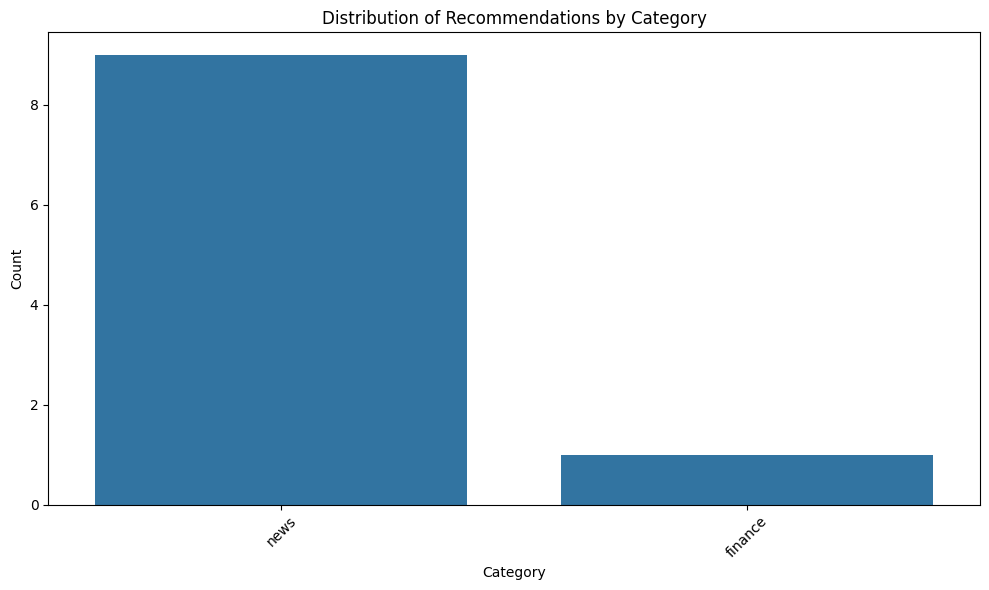

<Figure size 1000x600 with 0 Axes>

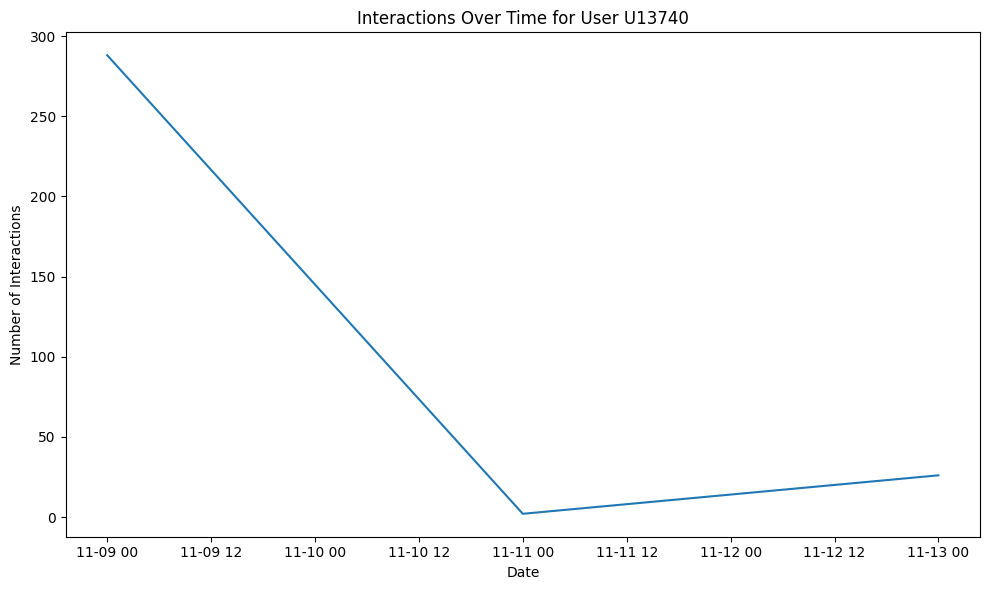

In [30]:
def main():
    # Sample usage
    print("Loading data...")
    
    # Assume behaviors_df and news_df are loaded as in your code
    
    print("Building recommendation engine...")
    results = build_and_evaluate_recommender(behaviors_df, news_df)
    
    print("Evaluation results:")
    print(f"Precision@10: {results['metrics']['precision@k']:.4f}")
    print(f"NDCG@10: {results['metrics']['ndcg@k']:.4f}")
    
    # Get a sample user for recommendations
    sample_user = behaviors_df['user_id'].iloc[0]
    print(f"\nGenerating recommendations for user {sample_user}...")
    
    # Generate recommendations for the sample user
    recommendations = get_recommendations_for_user(
        sample_user, 
        results['hybrid_recommender'], 
        behaviors_df, 
        news_df, 
        n=10
    )
    
    # Display recommendations
    print("\nTop 10 Recommendations:")
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec['title']} ({rec['category']}/{rec['subcategory']})")
    
    # Analyze recommendation diversity
    rec_ids = [rec['news_id'] for rec in recommendations]
    diversity = analyze_recommendation_diversity(rec_ids, news_df)
    
    print("\nRecommendation Diversity:")
    print(f"Category Distribution: {diversity['category_distribution']}")
    print(f"Diversity Score (Normalized Entropy): {diversity['normalized_entropy']:.4f}")
    
    # Create visualization of recommendation distribution
    plt.figure(figsize=(10, 6))
    plot_recommendation_distribution(rec_ids, news_df)
    plt.savefig('recommendation_distribution.png')
    print("\nSaved recommendation distribution plot to 'recommendation_distribution.png'")
    
    # Create visualization of user interactions
    plt.figure(figsize=(10, 6))
    visualize_user_interactions(behaviors_df, sample_user)
    plt.savefig('user_interactions.png')
    print(f"Saved user interaction plot to 'user_interactions.png'")
    
    print("\nRecommendation system evaluation complete.")
    
    return results

if __name__ == "__main__":
    main()